# Data Mining & Machine Learning Pipeline
This notebook demonstrates the **exact** linear, step-by-step pipeline for the Startup Country Advisor project. It strictly incorporates all the logic from `data_pipeline.py`, `seaborn_viz.py`, and `ml_models.py` sequentially without function wrappers.


## 1. Imports and Dependencies


In [16]:
import os
# 🐛 Fix for Joblib/Loky CPU core counting bug on Windows (Anaconda)
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
os.environ['OMP_NUM_THREADS'] = '1'


# Uncomment and run if using Google Colab
# !pip install pandas numpy seaborn matplotlib scikit-learn xgboost

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, label_binarize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.feature_selection import SelectKBest, f_classif

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Blues_d")


## 2. Configuration & Constants
We define the dataset path, exact column mappings, and sectoral weights used in the application.


In [17]:

DATA_PATH = "data/countries.csv"  # File name mapping to Google Colab

COLUMN_MAP = {
    "Country": "country",
    "Economy: Real GDP (purchasing power parity)": "gdp_ppp",
    "Economy: Real GDP per capita": "gdp_per_capita",
    "Economy: Real GDP growth rate": "gdp_growth",
    "Economy: Inflation rate (consumer prices)": "inflation",
    "Economy: Unemployment rate": "unemployment",
    "People and Society: Population - total": "population",
    "Communications: Internet users - percent of population": "internet_users_pct",
    "Economy: Taxes and other revenues": "tax_revenue",
    "Economy: Public debt": "public_debt",
    "Economy: Exports": "exports",
    "Economy: Imports": "imports",
    "Economy: Labor force": "labor_force",
    "Energy: Electricity - consumption": "electricity_production",
    "Communications: Telephones - mobile cellular - total subscriptions": "mobile_phones",
    "People and Society: Literacy - total population": "literacy",
}

NUMERIC_COLS = list(COLUMN_MAP.values())[1:]
FEATURE_COLS = [
    "market_size_score", "digital_score", "economic_stability", 
    "growth_potential", "infrastructure_score", "trade_openness", "human_capital"
]

N_CLUSTERS = 5

SECTOR_WEIGHTS = {
    "saas": {
        "digital_score": 0.30,
        "human_capital": 0.25,
        "economic_stability": 0.20,
        "market_size_score": 0.15,
        "trade_openness": 0.10,
        "growth_potential": 0.00,
        "infrastructure_score": 0.00,
    }
}


## 3. Data Loading
Loading the raw dataset and selecting target features.


In [18]:

print("Loading data...")
try:
    df_raw = pd.read_csv(DATA_PATH, encoding="utf-8", low_memory=False)
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding="latin-1", low_memory=False)

# Fuzzy exact matching for columns
found = {}
for raw_name, clean_name in COLUMN_MAP.items():
    if raw_name in df_raw.columns:
        found[raw_name] = clean_name

keyword_map = {
    "country": ["country", "name"],
    "gdp_ppp": ["purchasing power parity", "gdp (ppp)", "gdp ppp", "real gdp (purchasing"],
    "gdp_per_capita": ["per capita", "gdp per capita", "real gdp per capita"],
    "gdp_growth": ["real growth rate", "gdp growth", "real gdp growth"],
    "inflation": ["inflation rate", "consumer prices"],
    "unemployment": ["unemployment rate"],
    "population": ["population - total", "population"],
    "internet_users_pct": ["internet users - percent", "internet users"],
    "tax_revenue": ["taxes and other revenues", "tax revenue"],
    "public_debt": ["public debt"],
    "exports": ["economy: exports"],
    "imports": ["economy: imports"],
    "labor_force": ["labor force"],
    "electricity_production": ["electricity - consumption", "electricity - production", "electricity production"],
    "mobile_phones": ["mobile cellular - total", "mobile cellular"],
    "literacy": ["literacy - total population", "literacy"],
}

found_clean_names = set(found.values())
for clean_name, keywords in keyword_map.items():
    if clean_name in found_clean_names:
        continue
    for col in df_raw.columns:
        col_lower = col.lower()
        if any(kw.lower() in col_lower for kw in keywords):
            if "note" in col_lower or "partner" in col_lower or "commodit" in col_lower:
                continue
            found[col] = clean_name
            found_clean_names.add(clean_name)
            break

df = df_raw[list(found.keys())].rename(columns=found)
df = df.dropna(subset=["country"])
df["country"] = df["country"].str.strip().str.title()
df = df.reset_index(drop=True)

print(f"Data loading step complete. Shape: {df.shape}")
display(df.head(3))


Loading data...
Data loading step complete. Shape: (258, 16)


,country,gdp_ppp,gdp_per_capita,gdp_growth,inflation,unemployment,population,internet_users_pct,tax_revenue,public_debt,exports,imports,labor_force,electricity_production,mobile_phones,literacy
0,Afghanistan,$82.595 billion (2023 est.)$80.416 billion (20...,"$2,000 (2023 est.)$2,000 (2022 est.)$2,100 (20...",2.71% (2023 est.)-6.24% (2022 est.)-20.74% (20...,2.3% (2019 est.)0.63% (2018 est.)4.98% (2017 e...,14.39% (2023 est.)14.1% (2022 est.)11.93% (202...,"40,121,552",18% (2020 est.),9.9% (of GDP) (2017 est.)note: central governm...,7% of GDP (2017 est.),$1.476 billion (2020 est.)$1.516 billion (2019...,$6.983 billion (2020 est.)$7.371 billion (2019...,8.696 million (2023 est.)note: number of peopl...,5.994 billion kWh (2022 est.),23 million (2023 est.),37.3%
1,Akrotiri,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,$50.098 billion (2023 est.)$48.201 billion (20...,"$18,200 (2023 est.)$17,400 (2022 est.)$16,400 ...",3.94% (2023 est.)4.83% (2022 est.)8.91% (2021 ...,4.76% (2023 est.)6.73% (2022 est.)2.04% (2021 ...,11.58% (2023 est.)11.59% (2022 est.)12.47% (20...,"3,107,100",83% (2023 est.),18.1% (of GDP) (2021 est.)note: central govern...,81.92% of GDP (2021 est.)note: central governm...,$9.099 billion (2023 est.)$7.057 billion (2022...,$10.374 billion (2023 est.)$9.016 billion (202...,1.371 million (2023 est.)note: number of peopl...,6.5 billion kWh (2022 est.),2.61 million (2023 est.),98.4%


## 4. Data Cleaning
Extract numeric figures, drop columns missing >60%, and impute median.


In [19]:

def extract_numeric(value):
    if pd.isna(value): return np.nan
    s = str(value).lower().strip()
    
    multipliers = {"trillion": 1e12, "billion": 1e9, "million": 1e6, "thousand": 1e3}
    mult = 1.0
    for w, m in multipliers.items():
        if w in s:
            mult = m
            break
            
    match = re.search(r"[-+]?\d[\d,]*\.?\d*", s)
    if match:
        try: return float(match.group().replace(",", "")) * mult
        except: return np.nan
    return np.nan

# Extract numerics dynamically
numeric_cols_present = [c for c in NUMERIC_COLS if c in df.columns]
for col in numeric_cols_present:
    df[col] = df[col].apply(extract_numeric)

# Drop missing above threshold (0.60 meaning keeping columns with at least 40% filled)
threshold = 0.60
missing_frac = df[numeric_cols_present].isna().mean()
cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

# Impute median
numeric_cols_present = [c for c in NUMERIC_COLS if c in df.columns]
for col in numeric_cols_present:
    df[col] = df[col].fillna(df[col].median())

print("Data numeric extraction and cleaning complete!")
display(df.head(3))


Data numeric extraction and cleaning complete!


,country,gdp_ppp,gdp_per_capita,gdp_growth,inflation,unemployment,population,internet_users_pct,tax_revenue,public_debt,exports,imports,labor_force,electricity_production,mobile_phones,literacy
0,Afghanistan,8.259500e+10,2000.0,2.710,2.300,14.390,40121552.0,18.0,9.900,7.00,1.476000e+09,6.983000e+09,8696000.0,5.994000e+09,23000000.0,37.3
1,Akrotiri,6.733600e+10,17900.0,2.925,5.095,5.505,5437249.0,78.8,17.945,50.70,1.195650e+10,1.326000e+10,3183000.0,9.622000e+09,7050000.0,95.0
2,Albania,5.009800e+10,18200.0,3.940,4.760,11.580,3107100.0,83.0,18.100,81.92,9.099000e+09,1.037400e+10,1371000.0,6.500000e+09,2610000.0,98.4


## 5. Feature Engineering
Producing the 7 exact composite scores defined in the architecture.


In [20]:

eps = 1e-9

def safe_log(series):
    return np.log1p(series.clip(lower=0))

# 1. Market Size Score
if "population" in df.columns and "gdp_ppp" in df.columns:
    df["market_size_score"] = safe_log(df["population"]) * safe_log(df["gdp_ppp"])
else:
    df["market_size_score"] = safe_log(df.get("population", pd.Series([0] * len(df))))

# 2. Digital penetration
if "internet_users_pct" in df.columns:
    df["digital_score"] = df["internet_users_pct"].clip(0, 100)
elif "internet_users" in df.columns and "population" in df.columns:
    df["digital_score"] = (df["internet_users"] / (df["population"] + eps)) * 100
    df["digital_score"] = df["digital_score"].clip(0, 100)
else:
    df["digital_score"] = 0.0

# 3. Economic Stability
stability = 100.0
if "inflation" in df.columns:
    stability = stability - df["inflation"].clip(0, 100)
if "public_debt" in df.columns:
    stability = stability - (df["public_debt"] / 10).clip(0, 50)
df["economic_stability"] = stability.clip(0, 100) if isinstance(stability, pd.Series) else pd.Series([stability] * len(df))

# 4. Growth Potential
growth = pd.Series([5.0] * len(df), index=df.index)
if "gdp_growth" in df.columns:
    growth = df["gdp_growth"].clip(-5, 20)
unemp_factor = 1.0
if "unemployment" in df.columns:
    unemp_factor = (100 - df["unemployment"].clip(0, 100)) / 100
df["growth_potential"] = (growth * unemp_factor).clip(0, 20)

# 5. Infrastructure Score
infra = pd.Series([0.0] * len(df), index=df.index)
if "electricity_production" in df.columns:
    infra = infra + df["electricity_production"].clip(lower=0)
if "mobile_phones" in df.columns:
    infra = infra + df["mobile_phones"].clip(lower=0)
if "population" in df.columns:
    df["infrastructure_score"] = (infra / (df["population"] + eps)).clip(0, 100)
else:
    df["infrastructure_score"] = infra

# 6. Trade Openness
trade = pd.Series([0.0] * len(df), index=df.index)
if "exports" in df.columns:
    trade = trade + df["exports"].clip(lower=0)
if "imports" in df.columns:
    trade = trade + df["imports"].clip(lower=0)
if "gdp_ppp" in df.columns:
    df["trade_openness"] = (trade / (df["gdp_ppp"] + eps) * 100).clip(0, 200)
else:
    df["trade_openness"] = trade

# 7. Human Capital
literacy = pd.Series([70.0] * len(df), index=df.index)
if "literacy" in df.columns:
    literacy = df["literacy"].clip(0, 100)
gdp_pc_factor = 1.0
if "gdp_per_capita" in df.columns:
    gdp_pc_factor = 1 + (df["gdp_per_capita"].clip(0, 100000) / 100000)
df["human_capital"] = (literacy * gdp_pc_factor).clip(0, 200)

available_features = [f for f in FEATURE_COLS if f in df.columns]
print(f"Features created: {available_features}")
display(df[available_features].head(3))


Features created: ['market_size_score', 'digital_score', 'economic_stability', 'growth_potential', 'infrastructure_score', 'trade_openness', 'human_capital']


,market_size_score,digital_score,economic_stability,growth_potential,infrastructure_score,trade_openness,human_capital
0,440.087887,18.0,97.000,2.320031,100.0,10.241540,38.0460
1,386.679904,78.8,89.835,2.763979,100.0,37.448764,112.0050
2,368.307149,83.0,87.048,3.483748,100.0,38.869815,116.3088


## 6. Normalization & KMeans Clustering
Apply `MinMaxScaler`, cluster into 5 classes, and run PCA for 2D embedding.


In [21]:

# MinMax Scaling
scaler = MinMaxScaler()
df[available_features] = scaler.fit_transform(df[available_features].fillna(0))

# KMeans Clustering
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
X_cluster = df[available_features].fillna(0).values
df["cluster_id"] = km.fit_predict(X_cluster)

# Cluster Naming Heuristics
centroids = pd.DataFrame(km.cluster_centers_, columns=available_features)
names = {}
remaining = list(centroids.index)

if "economic_stability" in centroids.columns and "human_capital" in centroids.columns:
    advanced_idx = centroids.loc[remaining, ["economic_stability", "human_capital"]].mean(axis=1).idxmax()
    names[advanced_idx] = "Advanced Economies"
    remaining.remove(advanced_idx)

if remaining:
    frontier_idx = centroids.loc[remaining].mean(axis=1).idxmin()
    names[frontier_idx] = "Frontier Markets"
    remaining.remove(frontier_idx)

if remaining and "digital_score" in centroids.columns:
    digital_idx = centroids.loc[remaining, "digital_score"].idxmax()
    names[digital_idx] = "Digital Leapfrog Markets"
    remaining.remove(digital_idx)

if remaining and "growth_potential" in centroids.columns:
    emerging_idx = centroids.loc[remaining, "growth_potential"].idxmax()
    names[emerging_idx] = "Emerging Markets"
    remaining.remove(emerging_idx)

for idx in remaining:
    names[idx] = "Developing Economies"

df["cluster_name"] = df["cluster_id"].map(names)

# PCA for 2D display
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cluster)
df["pca_x"] = coords[:, 0]
df["pca_y"] = coords[:, 1]

print("Clusters and PCA mapping established!")
display(df[["country", "cluster_name", "pca_x", "pca_y"]].head())


Clusters and PCA mapping established!


,country,cluster_name,pca_x,pca_y
0,Afghanistan,Emerging Markets,-0.726210,0.095656
1,Akrotiri,Developing Economies,0.001401,-0.145892
2,Albania,Developing Economies,0.046400,-0.154811
3,Algeria,Developing Economies,-0.182540,-0.223048
4,American Samoa,Emerging Markets,-0.367511,-0.033817


## 7. Opportunity Scoring
Applying Tech Profile weights.


In [22]:

# Weight application for tech/saas
weights = SECTOR_WEIGHTS["saas"]
score = pd.Series(0.0, index=df.index)
for feature, weight in weights.items():
    if weight > 0 and feature in df.columns:
        score += weight * df[feature]

df["opportunity_score"] = (score * 100).round(2)
df["rank"] = df["opportunity_score"].rank(ascending=False, method="min").astype(int)

# Specific visualization for Tunisia
print("Opportunity Assessment for Tunisia (Tech/SaaS):")
tunisia_data = df[df['country'] == 'Tunisia']
if not tunisia_data.empty:
    display(tunisia_data[['country', 'cluster_name', 'opportunity_score', 'rank'] + available_features])
else:
    print("Country not found in dataset.")


Opportunity Assessment for Tunisia (Tech/SaaS):


,country,cluster_name,opportunity_score,rank,market_size_score,digital_score,economic_stability,growth_potential,infrastructure_score,trade_openness,human_capital
235,Tunisia,Developing Economies,56.76,172,0.496032,0.711111,0.840434,0.001715,1.0,0.135916,0.392649


## 8. Exploratory Data Analysis (EDA)
Outlier boxplots, distributions, and correlation map.


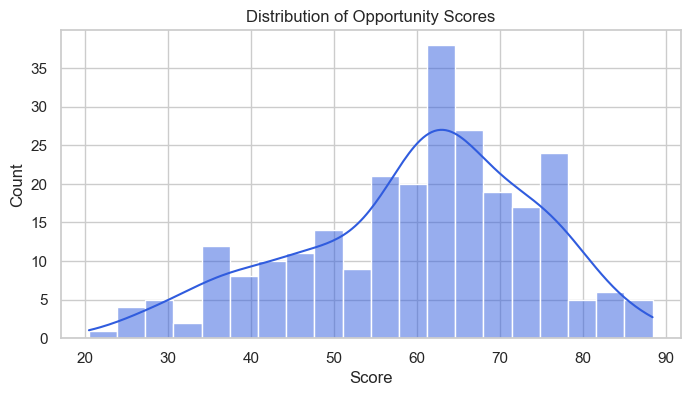

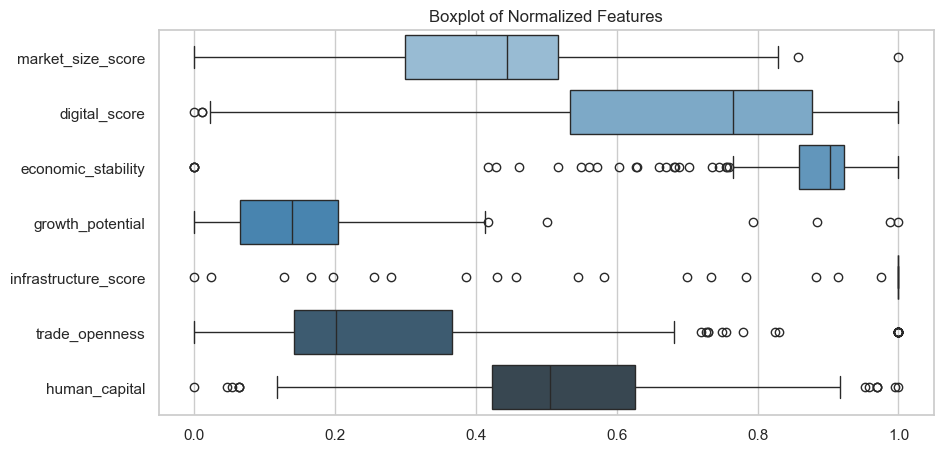

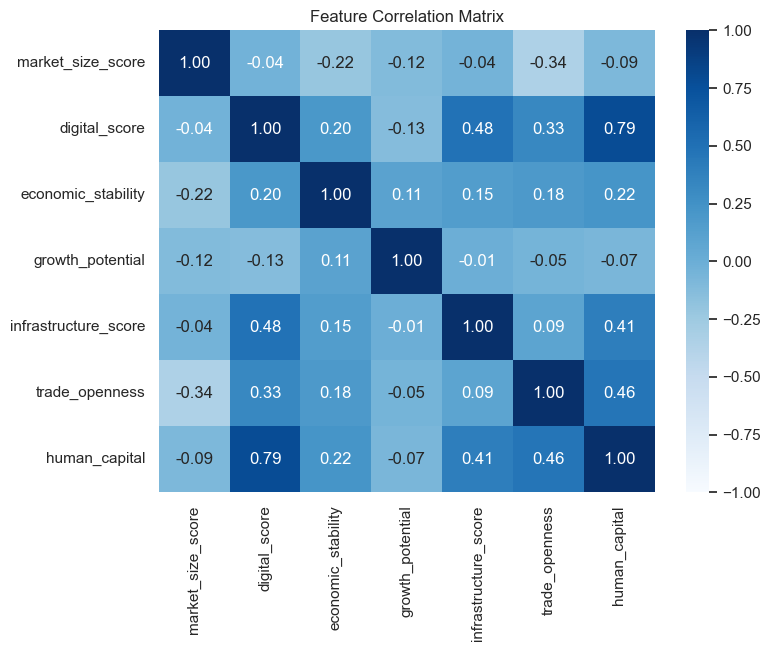

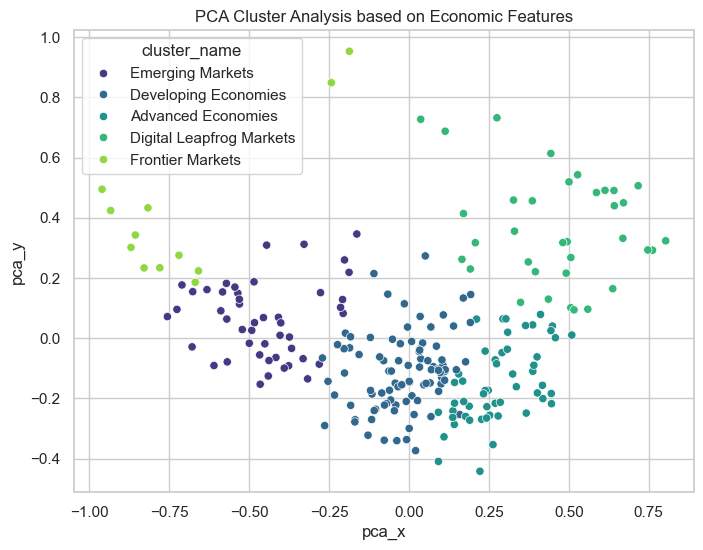

In [23]:

# Distribution of Opportunity Score
plt.figure(figsize=(8, 4))
sns.histplot(df["opportunity_score"], bins=20, kde=True, color="#305CDE")
plt.title("Distribution of Opportunity Scores")
plt.xlabel("Score")
plt.show()

# Boxplots for Outliers across Features
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[available_features], orient="h", palette="Blues_d")
plt.title("Boxplot of Normalized Features")
plt.show()

# Correlation Matrix
plt.figure(figsize=(8, 6))
corr = df[available_features].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

# Cluster Distribution Scatter
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="pca_x", y="pca_y", hue="cluster_name", palette="viridis")
plt.title("PCA Cluster Analysis based on Economic Features")
plt.show()


## 9. Machine Learning Target Preparation (Opportunity Level)
We build our 3 level categorical task logic from `ml_models.py` and run F-tests.


In [24]:

# Target Variable definition (from ml_models.py: 'opportunity' task)
score_quantiles = df["opportunity_score"]
q33 = score_quantiles.quantile(0.33)
q66 = score_quantiles.quantile(0.66)
y = pd.cut(
    score_quantiles,
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]  # Low, Medium, High
).astype(int)

X = df[available_features].fillna(0)

# Feature Selection (SelectKBest ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X, y)
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print(f"ANOVA feature selection retained 5 key metrics: {selected_features}")


ANOVA feature selection retained 5 key metrics: ['digital_score', 'economic_stability', 'infrastructure_score', 'trade_openness', 'human_capital']


## 10. GridSearch & Multi-Class ML Modeling
Executing the complete `GridSearchCV` configurations for `RandomForest`, `SVM`, and `XGBoost`.


Training cross-validated models... (This may take a moment)


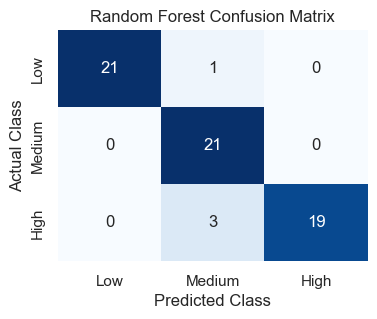

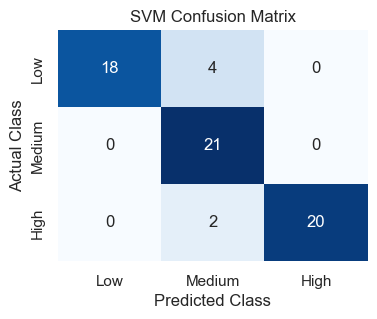

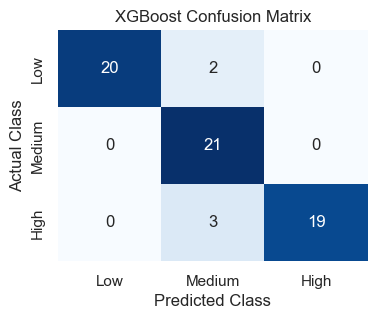


🧠 ML Performance Summary:


,Model,Best CV Score,Test Accuracy,Test F1-Score,CV Mean ± Std
0,Random Forest,0.896577,0.938462,0.939270,0.8915 ± 0.0186
1,SVM,0.912202,0.907692,0.909652,0.9147 ± 0.0258
2,XGBoost,0.875744,0.923077,0.924747,0.8797 ± 0.0322


In [25]:

X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.25, random_state=42, stratify=y
)

# Equivalent ModelManager registry configurations
model_registry = {
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [50, 100], "max_depth": [5, 10]}
    },
    "SVM": {
        "estimator": SVC(random_state=42, probability=True),
        "params": {"C": [0.1, 1, 10], "kernel": ["rbf"]}
    },
    "XGBoost": {
        "estimator": XGBClassifier(objective="multi:softmax", num_class=3, eval_metric="mlogloss", random_state=42),
        "params": {"n_estimators": [100], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]}
    }
}

evaluation_results = []
trained_models = {}

print("Training cross-validated models... (This may take a moment)")
for name, config in model_registry.items():
    grid = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["params"],
        cv=4,
        scoring="accuracy",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    trained_models[name] = best
    
    y_pred = best.predict(X_test)
    
    cv_scores = cross_val_score(best, X[selected_features], y, cv=4, scoring="accuracy")
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    evaluation_results.append({
        "Model": name,
        "Best CV Score": grid.best_score_,
        "Test Accuracy": acc,
        "Test F1-Score": f1,
        "CV Mean ± Std": f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
    })
    
    # Render confusion matrix explicitly
    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False, 
                xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

# Show overall results
print("\n🧠 ML Performance Summary:")
display(pd.DataFrame(evaluation_results))


## 11. Custom Visualizations: ROC Curve Analysis
Calculate macro-averaged properties natively avoiding function abstraction.


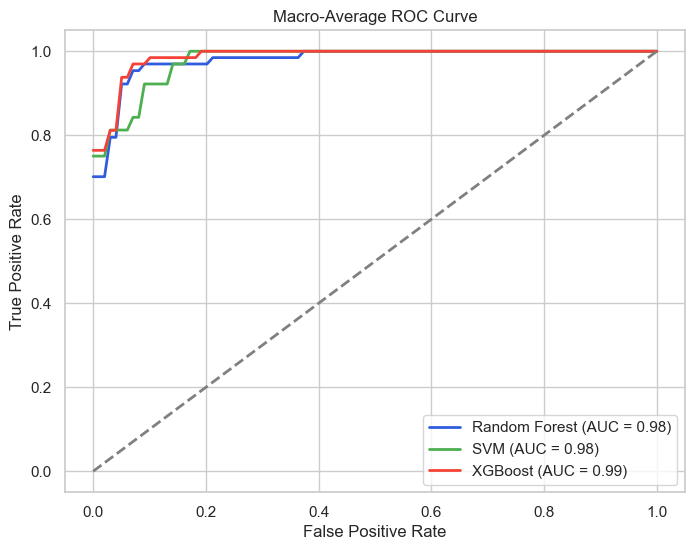

In [26]:

# Computing ROC data exclusively on best performed models
plt.figure(figsize=(8, 6))

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
all_fpr = np.linspace(0, 1, 100)

colors = ["#305CDE", "#4CAF50", "#F44336"]

for (name, model), color in zip(trained_models.items(), colors):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(3):
            if i < y_proba.shape[1]:
                fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
        mean_tpr /= 3
        roc_auc = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend(loc="lower right")
plt.show()
